Iniciando análisis de rozamiento de traslación...
Cargando y procesando datos para análisis de traslación...


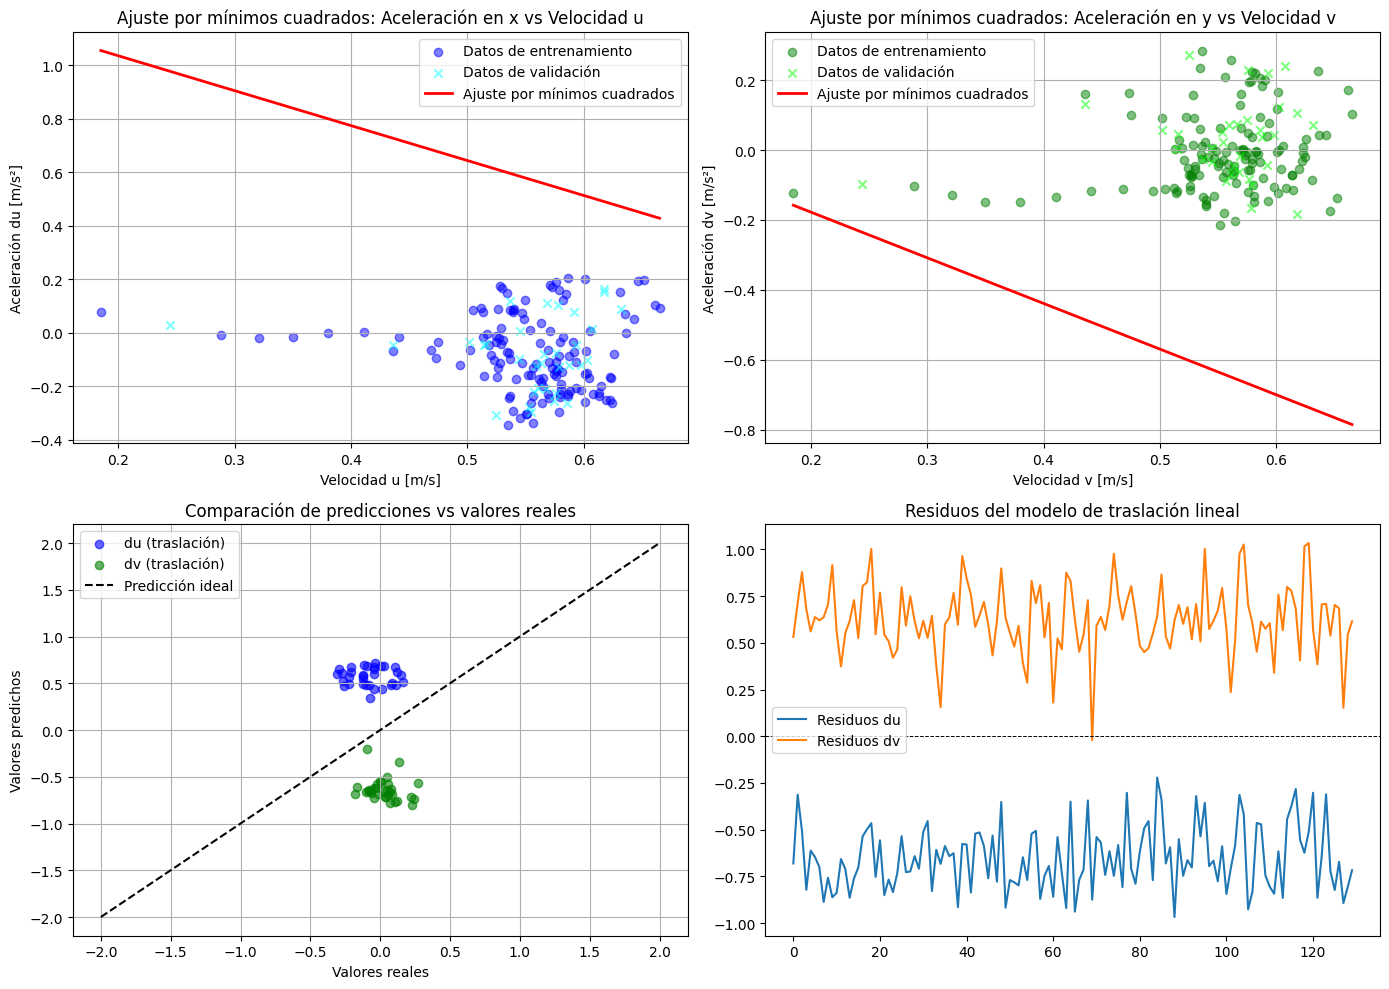

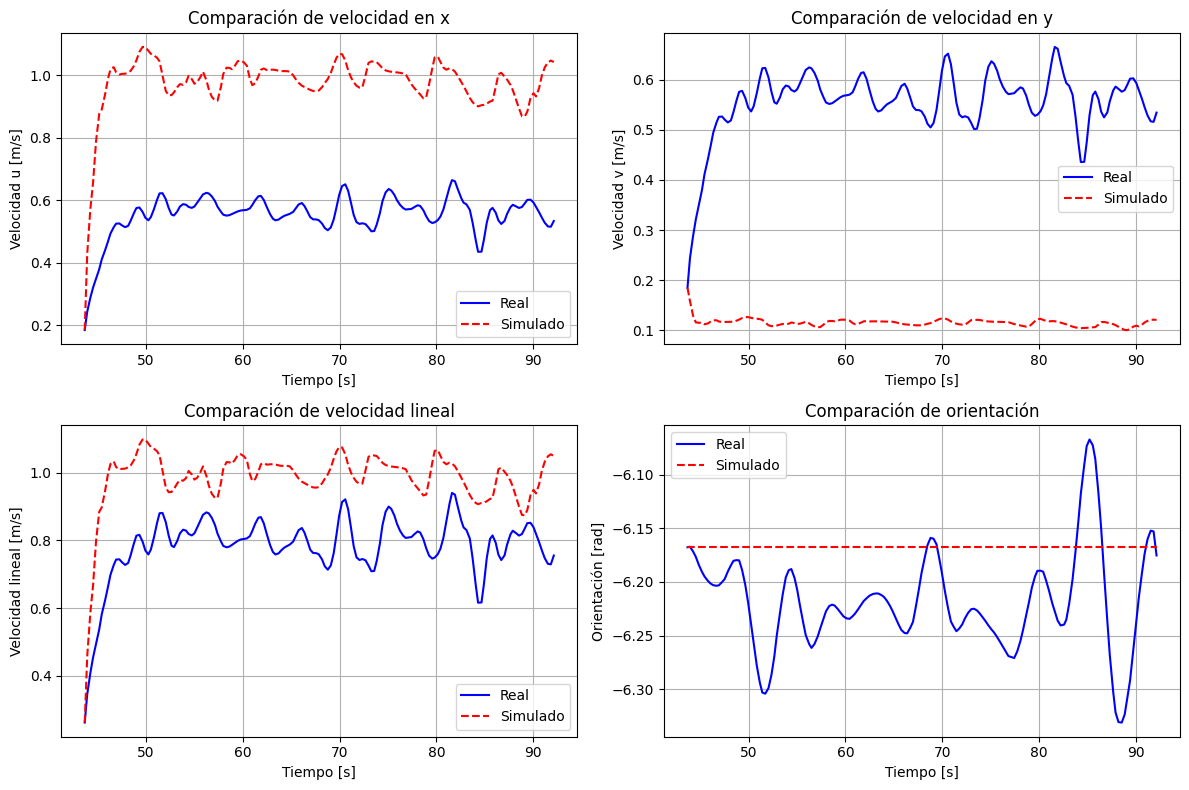

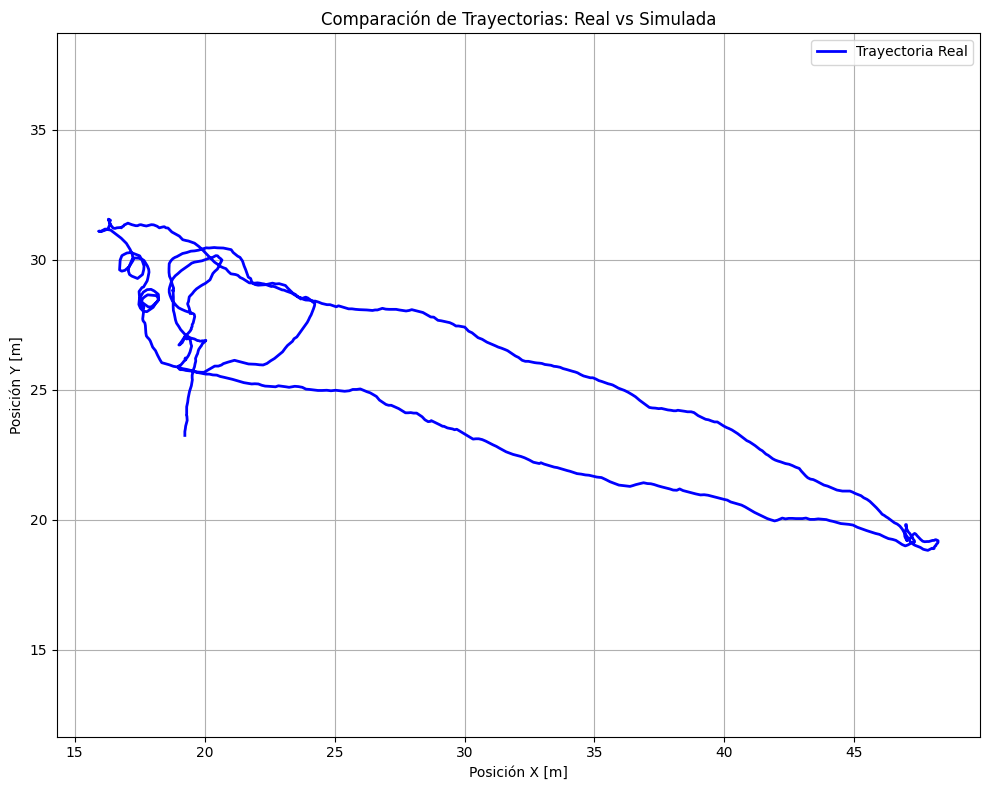


--- Estimación del modelo de traslación lineal ---
Umbral traslación: 0.2

Coeficiente de traslación (modelo lineal):
mu = 1.307712 (coeficiente de fricción general)

--- Validación cruzada ---
MSE traslación x: 0.449568
MSE traslación y: 0.475981


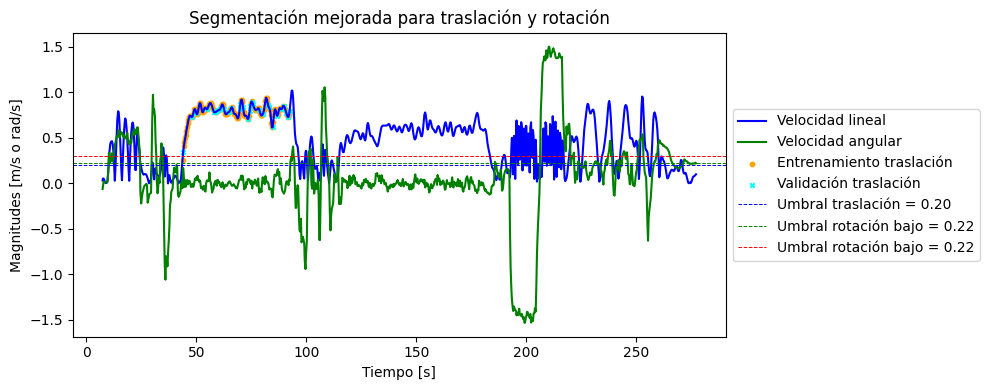


Análisis de traslación completado con éxito.
Los resultados se han guardado en los archivos 'ajuste_traslacion.png', 'simulacion_traslacion.png' y 'trayectoria_comparacion.png'


In [21]:
"""
Análisis de rozamiento de traslación para vehículo marino

Este script se enfoca exclusivamente en el análisis del rozamiento de traslación,
separado del análisis de rotación.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import least_squares
from scipy.signal import butter, filtfilt
from scipy.signal import savgol_filter

# Funciones auxiliares
def extraccion_datos(var, pos):
    """
    Extrae datos de un archivo de registro.
    
    Args:
        var: Variable a extraer
        pos: Posición de la variable en la línea
    
    Returns:
        Tupla con los datos extraídos y sus tiempos correspondientes
    """
    home_dir = os.path.expanduser("~")
    ruta_datos = os.path.join(home_dir, "paparazzi", "var", "logs", "25_05_28__16_27_03.data")
    
    dato = []
    tiempo = []
    with open(ruta_datos, "r", encoding="utf-8") as file:
        for line in file:
            if var in line:
                campos = line.strip().split()
                if campos[2] == var:
                    dato.append(float(campos[pos]))
                    tiempo.append(float(campos[0]))
    return np.array(dato), np.array(tiempo)


def filtrado_tiempo_comun(t_comun, dt_min=0.1, dt_max=1):
    """
    Filtra los tiempos para obtener intervalos regulares.
    
    Args:
        t_comun: Array de tiempos a filtrar
        dt_min: Intervalo mínimo entre muestras
        dt_max: Intervalo máximo entre muestras
    
    Returns:
        Tiempos filtrados e índices correspondientes
    """
    dt = np.gradient(t_comun)
    mask = (dt >= dt_min) & (dt <= dt_max)
    mask[0] = True
    indices = np.where(mask)[0]
    t_filtrado = t_comun[indices]
    
    return t_filtrado, indices


def interp_to_common(t_original, data_original, t_comun):
    """
    Interpola datos a una base de tiempo común.
    
    Args:
        t_original: Tiempos originales
        data_original: Datos originales
        t_comun: Base de tiempo común para interpolación
    
    Returns:
        Datos interpolados
    """
    interp_func = interp1d(t_original, data_original, kind='linear', bounds_error=False, fill_value="extrapolate")
    return interp_func(t_comun)

def normalize_angle(angle):
    """
    Normaliza un ángulo al rango [-π, π].
    
    Args:
        angle: Ángulo a normalizar
        
    Returns:
        Ángulo normalizado
    """
    return ((angle + np.pi) % (2 * np.pi)) - np.pi

def filtro_butterworth(data, cutoff_freq, fs, order=4):
    """
    Aplica un filtro Butterworth pasa-bajos.
    
    Args:
        data: Datos a filtrar
        cutoff_freq: Frecuencia de corte (Hz)
        fs: Frecuencia de muestreo (Hz)
        order: Orden del filtro
        
    Returns:
        Datos filtrados
    """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff_freq / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

def safe_multiply(a, b, max_val=1e6):
    """
    Multiplicación segura que evita desbordamientos.
    
    Args:
        a, b: Valores a multiplicar
        max_val: Valor máximo permitido
        
    Returns:
        Resultado de la multiplicación, limitado a max_val
    """
    try:
        result = a * b
        if np.isscalar(result):
            if not np.isfinite(result) or abs(result) > max_val:
                return np.sign(result) * max_val if result != 0 else 0.0
            return result
        else:
            # Manejar arrays
            result = np.where(np.isfinite(result), result, np.sign(result) * max_val)
            result = np.where(np.abs(result) <= max_val, result, np.sign(result) * max_val)
            # Corregir casos donde el signo es 0
            result = np.where(result == 0, 0.0, result)
            return result
    except Exception as e:
        print(f"Error en safe_multiply: {e}")
        if np.isscalar(a) and np.isscalar(b):
            return 0.0
        else:
            return np.zeros_like(a if hasattr(a, 'shape') else b)

def safe_add(a, b, max_val=1e6):
    """
    Suma segura que evita desbordamientos.
    
    Args:
        a, b: Valores a sumar
        max_val: Valor máximo permitido
        
    Returns:
        Resultado de la suma, limitado a max_val
    """
    try:
        result = a + b
        if np.isscalar(result):
            if not np.isfinite(result) or abs(result) > max_val:
                return np.sign(result) * max_val if result != 0 else 0.0
            return result
        else:
            # Manejar arrays
            result = np.where(np.isfinite(result), result, np.sign(result) * max_val)
            result = np.where(np.abs(result) <= max_val, result, np.sign(result) * max_val)
            # Corregir casos donde el signo es 0
            result = np.where(result == 0, 0.0, result)
            return result
    except Exception as e:
        print(f"Error en safe_add: {e}")
        if np.isscalar(a) and np.isscalar(b):
            return 0.0
        else:
            return np.zeros_like(a if hasattr(a, 'shape') else b)

def limit_velocity(velocity, max_vel=5.0):
    """
    Limita la velocidad a un valor máximo físicamente razonable.
    
    Args:
        velocity: Valor de velocidad a limitar
        max_vel: Velocidad máxima permitida en m/s
        
    Returns:
        Velocidad limitada al rango [-max_vel, max_vel]
    """
    return np.clip(velocity, -max_vel, max_vel)

def rk4_step(y, t, dt, f):
    """
    Integración mediante Runge-Kutta de 4º orden.
    
    Args:
        y: Estado actual
        t: Tiempo actual
        dt: Paso de tiempo
        f: Función que calcula la derivada del estado
        
    Returns:
        Nuevo estado
    """
    k1 = f(y, t)
    k2 = f(y + dt/2 * k1, t + dt/2)
    k3 = f(y + dt/2 * k2, t + dt/2)
    k4 = f(y + dt * k3, t + dt)
    return y + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

def verificar_consistencia_orientacion(theta_sim, orientacion_real, t_sim, ventana=50):
    """
    Verifica la consistencia entre orientación simulada y real.
    
    Args:
        theta_sim: Orientación simulada
        orientacion_real: Orientación real
        t_sim: Tiempos de simulación
        ventana: Tamaño de la ventana de análisis
        
    Returns:
        Orientación simulada corregida
    """
    theta_corregida = theta_sim.copy()
    
    for i in range(ventana, len(t_sim)):
        # Calcular error medio en la ventana anterior
        error_medio = np.mean(np.abs(normalize_angle(
            orientacion_real[i-ventana:i] - theta_sim[i-ventana:i])))
        
        # Si el error supera un umbral, aplicar corrección
        if error_medio > np.pi/3:  # Más de 60 grados de error promedio
            print(f"Corrección aplicada en t={t_sim[i]}, error={error_medio}")
            # Reiniciar la orientación simulada al valor real
            theta_corregida[i] = orientacion_real[i]
            # Propagar la corrección a los siguientes pasos
            if i+1 < len(t_sim):
                theta_corregida[i+1:] = theta_sim[i+1:] + (orientacion_real[i] - theta_sim[i])
            break
    
    return theta_corregida

def tramo_minima_dependencia(indices, v_lineal, omega_abs, tipo='traslacion', min_length=10):
    """
    Selecciona el tramo continuo que minimiza la dependencia cruzada.
    
    Args:
        indices: Array de índices a analizar
        v_lineal: Array de velocidades lineales
        omega_abs: Array de velocidades angulares absolutas
        tipo: 'traslacion' o 'rotacion', indica el tipo de tramo a seleccionar
        min_length: Longitud mínima que debe tener un segmento para ser considerado
        
    Returns:
        Array con el segmento que minimiza la dependencia cruzada
    """
    if len(indices) == 0:
        return indices
    
    # Detecta rupturas de continuidad
    cortes = np.where(np.diff(indices) != 1)[0] + 1
    segmentos = np.split(indices, cortes)
    
    # Filtra segmentos de al menos longitud mínima
    segmentos_validos = [seg for seg in segmentos if len(seg) >= min_length]
    
    if not segmentos_validos:
        return np.array([], dtype=int)
    
    # Calcula la métrica de dependencia para cada segmento
    if tipo == 'traslacion':
        # Para traslación, queremos minimizar la velocidad angular
        metricas = [np.mean(omega_abs[seg]) for seg in segmentos_validos]
        # Normalizar por la velocidad lineal para favorecer segmentos con alta velocidad lineal
        metricas_normalizadas = [metricas[i] / (np.mean(v_lineal[seg]) + 1e-6) 
                               for i, seg in enumerate(segmentos_validos)]
        # Seleccionar el segmento con la menor métrica normalizada
        mejor_segmento = segmentos_validos[np.argmin(metricas_normalizadas)]
        
    elif tipo == 'rotacion':
        # Para rotación, queremos minimizar la velocidad lineal
        metricas = [np.mean(v_lineal[seg]) for seg in segmentos_validos]
        # Normalizar por la velocidad angular para favorecer segmentos con alta velocidad angular
        metricas_normalizadas = [metricas[i] / (np.mean(omega_abs[seg]) + 1e-6) 
                               for i, seg in enumerate(segmentos_validos)]
        # Seleccionar el segmento con la menor métrica normalizada
        mejor_segmento = segmentos_validos[np.argmin(metricas_normalizadas)]
    
    return mejor_segmento
    
from scipy.stats import pearsonr

def tramo_mayor_correlacion(indices, v_lineal, omega_abs):
    """
    Selecciona el tramo donde la velocidad lineal y angular están más correlacionadas.
    
    Args:
        indices: array de índices válidos
        v_lineal: array de velocidades lineales
        omega_abs: array de velocidades angulares absolutas
        
    Returns:
        Array con los índices del mejor segmento
    """
    if len(indices) == 0:
        return indices
        
    cortes = np.where(np.diff(indices) != 1)[0] + 1
    segmentos = np.split(indices, cortes)
    segmentos_largos = [seg for seg in segmentos if len(seg) > 1]

    correlaciones = [
        pearsonr(v_lineal[seg], omega_abs[seg])[0] if len(seg) > 2 else 0
        for seg in segmentos_largos
    ]
    
    # Seleccionar el segmento con mayor correlación positiva
    mejor_segmento = segmentos_largos[np.argmax(correlaciones)]
    return mejor_segmento


def tramo_mas_largo(indices):
    """
    Devuelve el sub-array continuo más largo dentro de `indices`.
    
    Args:
        indices: Array de índices a analizar
        
    Returns:
        Array con el segmento continuo más largo
    """
    if len(indices) == 0:
        return indices
    # detecta rupturas de continuidad
    cortes = np.where(np.diff(indices) != 1)[0] + 1
    segmentos = np.split(indices, cortes)
    # filtra segmentos de al menos longitud 2
    segmentos_largos = [seg for seg in segmentos if len(seg) > 1]
    if not segmentos_largos:
        return np.array([], dtype=int)
    # devuelve el más largo
    return max(segmentos_largos, key=len)

def tramo_mayor_velocidad(indices, velocidad):
    """
    Devuelve, dentro de los segmentos continuos en `indices`,
    aquel cuya velocidad (en el array `velocidad`) alcance el valor máximo.
    
    Args:
        indices: Array de índices a analizar
        velocidad: Array de velocidades correspondientes
        
    Returns:
        Array con el segmento que contiene la mayor velocidad
    """
    if len(indices) == 0:
        return indices
    cortes = np.where(np.diff(indices) != 1)[0] + 1
    segmentos = np.split(indices, cortes)
    segmentos_largos = [seg for seg in segmentos if len(seg) > 1]
    if not segmentos_largos:
        return np.array([], dtype=int)
    # selecciona el segmento con mayor pico de velocidad
    return max(segmentos_largos, key=lambda seg: np.max(velocidad[seg]))


def split_train_validation(indices, train_ratio=0.8):
    """
    Divide los índices en conjuntos de entrenamiento y validación.
    
    Args:
        indices: Array de índices a dividir
        train_ratio: Proporción para el conjunto de entrenamiento (0-1)
        
    Returns:
        Tupla con (índices_entrenamiento, índices_validación)
    """
    n = len(indices)
    n_train = int(train_ratio * n)
    # Aseguramos que la división sea aleatoria pero reproducible
    np.random.seed(42)
    indices_shuffled = np.random.permutation(indices)
    train_indices = indices_shuffled[:n_train]
    valid_indices = indices_shuffled[n_train:]
    return train_indices, valid_indices

# ===== FUNCIÓN GENERAL DE ROZAMIENTO CON UN ÚNICO PARÁMETRO =====
def calcular_rozamiento(u, v, orientacion, mu):
    """
    Función general para calcular el rozamiento en ambas direcciones usando un único parámetro mu.
    Esta función permite derivar mu_x y mu_y a partir de mu y la orientación.
    
    Args:
        u: Velocidad en dirección x
        v: Velocidad en dirección y
        orientacion: Orientación del vehículo (ángulo en radianes)
        mu: Coeficiente de rozamiento general
    
    Returns:
        Tupla con (rozamiento_x, rozamiento_y)
    """
    # Componentes de orientación
    a = np.cos(orientacion)
    b = np.sin(orientacion)
    
    # Aquí puedes implementar tu propia regla para derivar mu_x y mu_y a partir de mu
    # Por ejemplo, podrían ser funciones de la orientación o simplemente proporcionales a mu
    # Esta es una implementación de ejemplo que mantiene los términos completos
    mu_x = mu  # Puedes modificar esta relación según tus necesidades
    mu_y = mu  # Puedes modificar esta relación según tus necesidades
    
    # Términos lineales para rozamiento en x
    term1_x_lin = (a**2) * mu_x * u
    term2_x_lin = (b**2) * mu_y * u
    term3_x_lin = a * b * v * (mu_x - mu_y)  # Este término NO se anula si mu_x ≠ mu_y
    
    # Rozamiento total en x
    rozamiento_x = term1_x_lin + term2_x_lin + term3_x_lin
    
    # Términos lineales para rozamiento en y
    term1_y_lin = (b**2) * mu_x * v
    term2_y_lin = (a**2) * mu_y * v
    term3_y_lin = a * b * u * (mu_x - mu_y)  # Este término NO se anula si mu_x ≠ mu_y
    
    # Rozamiento total en y
    rozamiento_y = term1_y_lin + term2_y_lin + term3_y_lin
    
    return rozamiento_x, rozamiento_y

# Función específica para el análisis de traslación
def residuals_trans_lineal(params):
    """
    Función de residuos para el movimiento de traslación.
    Incluye solo términos lineales de fricción con un único parámetro mu.
    
    Args:
        params: [mu] - Coeficiente de fricción lineal general
    """
    # Extraer el único parámetro mu
    mu = params[0]
    
    # Calcular rozamiento usando la función general
    rozamiento_x, rozamiento_y = calcular_rozamiento(
        u_trans_smooth, v_trans_smooth, orientacion_trans, mu
    )
    
    a = np.cos(orientacion_trans)
    b = np.sin(orientacion_trans)
    
    # Residuos en x
    res_x = du_trans_smooth - (fa_trans * a - rozamiento_x)

    # Residuos en y
    res_y = dv_trans_smooth - (fa_trans * b - rozamiento_y)

    # Asegurar que los residuos sean finitos
    res_x = np.where(np.isfinite(res_x), res_x, 0.0)
    res_y = np.where(np.isfinite(res_y), res_y, 0.0)

    return np.concatenate((res_x, res_y))

def evaluate_model_trans_lineal(params, indices):
    """
    Evalúa el modelo de traslación lineal en los índices dados.
    
    Args:
        params: Parámetros del modelo [mu]
        indices: Índices donde evaluar el modelo
        
    Returns:
        Tupla con (du_pred, dv_pred, mse_x, mse_y)
    """
    u_eval = u_i[indices]
    v_eval = v_i[indices]
    du_eval = du[indices]
    dv_eval = dv[indices]
    fa_eval = T_L[indices] + T_R[indices]
    orientacion_eval = orientacion_i[indices]
    
    # Extraer el único parámetro mu
    mu = params[0]
    
    # Calcular rozamiento usando la función general
    rozamiento_x, rozamiento_y = calcular_rozamiento(
        u_eval, v_eval, orientacion_eval, mu
    )
    
    a = np.cos(orientacion_eval)
    b = np.sin(orientacion_eval)
    
    # Aceleración predicha en x con protección contra desbordamiento
    du_pred = fa_eval * a - rozamiento_x
    
    # Aceleración predicha en y con protección contra desbordamiento
    dv_pred = fa_eval * b - rozamiento_y
    
    # Asegurar que las predicciones sean finitas
    du_pred = np.where(np.isfinite(du_pred), du_pred, 0.0)
    dv_pred = np.where(np.isfinite(dv_pred), dv_pred, 0.0)
    
    # Error cuadrático medio
    mse_x = np.mean((du_eval - du_pred)**2)
    mse_y = np.mean((dv_eval - dv_pred)**2)
    
    return du_pred, dv_pred, mse_x, mse_y

def simulate_motion_traslacion(t_sim, u0, v0, theta0, fa_sim, params_trans):
    """
    Simula el movimiento de traslación del vehículo.
    
    Args:
        t_sim: Array de tiempos para la simulación
        u0: Velocidad inicial en x
        v0: Velocidad inicial en y
        theta0: Orientación inicial
        fa_sim: Array de fuerzas de propulsión
        params_trans: Parámetros del modelo de traslación [mu]
        
    Returns:
        Tupla con (u_sim, v_sim, theta_sim)
    """
    dt = np.diff(t_sim)
    n = len(t_sim)

    u_sim = np.zeros(n)
    v_sim = np.zeros(n)
    theta_sim = np.zeros(n)

    max_vel_lineal = 5.0  # m/s

    u_sim[0] = limit_velocity(u0, max_vel_lineal)
    v_sim[0] = limit_velocity(v0, max_vel_lineal)
    theta_sim[0] = theta0

    # Extraer el único parámetro mu
    mu = params_trans[0]
    
    for i in range(1, n):
        u_prev = u_sim[i-1]
        v_prev = v_sim[i-1]
        theta_prev = theta_sim[i-1]

        a = np.cos(theta_prev)
        b = np.sin(theta_prev)

        # Calcular rozamiento usando la función general
        rozamiento_x, rozamiento_y = calcular_rozamiento(
            u_prev, v_prev, theta_prev, mu
        )

        # TÉRMINOS DE TRASLACIÓN
        propulsion_x = fa_sim[i-1] * a
        du_sim = propulsion_x - rozamiento_x

        propulsion_y = fa_sim[i-1] * b
        dv_sim = propulsion_y - rozamiento_y

        u_next = u_prev + du_sim * dt[i-1]
        v_next = v_prev + dv_sim * dt[i-1]

        u_sim[i] = limit_velocity(u_next, max_vel_lineal)
        v_sim[i] = limit_velocity(v_next, max_vel_lineal)
        theta_sim[i] = theta_prev  # La orientación se mantiene constante en este modelo simplificado

        u_sim[i] = 0.0 if not np.isfinite(u_sim[i]) else u_sim[i]
        v_sim[i] = 0.0 if not np.isfinite(v_sim[i]) else v_sim[i]

        if i > 1:
            v_lineal_actual = np.sqrt(u_sim[i]**2 + v_sim[i]**2)
            v_lineal_anterior = np.sqrt(u_sim[i-1]**2 + v_sim[i-1]**2)
            # if v_lineal_actual > 1.5 * v_lineal_anterior and v_lineal_actual > 0.5:
            #     u_sim[i] *= 0.8
            #     v_sim[i] *= 0.8

    return u_sim, v_sim, theta_sim

def calcular_trayectoria(t, u, v, orientacion):
    """
    Calcula la trayectoria (posiciones x, y) a partir de las velocidades y orientación.
    
    Args:
        t: Array de tiempos
        u: Array de velocidades en dirección x (en el sistema del vehículo)
        v: Array de velocidades en dirección y (en el sistema del vehículo)
        orientacion: Array de orientaciones (ángulos en radianes)
        
    Returns:
        Tupla con (posiciones_x, posiciones_y)
    """
    # Inicializar arrays de posición
    n = len(t)
    x = np.zeros(n)
    y = np.zeros(n)
    
    # Calcular posiciones mediante integración de velocidades
    for i in range(1, n):
        dt = t[i] - t[i-1]
        
        # Velocidades en el sistema global
        vx_global = u[i-1] * np.cos(orientacion[i-1]) - v[i-1] * np.sin(orientacion[i-1])
        vy_global = u[i-1] * np.sin(orientacion[i-1]) + v[i-1] * np.cos(orientacion[i-1])
        
        # Integración simple (método de Euler)
        x[i] = x[i-1] + vx_global * dt
        y[i] = y[i-1] + vy_global * dt
    
    return x, y

def analizar_traslacion(rozamiento):
    """
    Función principal para ejecutar el análisis de traslación.
    """
    global u_i, v_i, du, dv, T_L, T_R, orientacion_i, v_lineal, omega_abs
    global indices_trans_train, indices_trans_valid
    global u_trans_smooth, v_trans_smooth, du_trans_smooth, dv_trans_smooth, fa_trans, orientacion_trans
    
    # Cargar y procesar datos
    print("Cargando y procesando datos para análisis de traslación...")
    
    # Extracción de datos
    escala_vel = 0.0000019
    x_raw, t_x = extraccion_datos("INS", 3)
    y_raw, t_x = extraccion_datos("INS", 4)
    u_raw, t_u = extraccion_datos("INS", 6)
    v_raw, t_v = extraccion_datos("INS", 7)

    escala_pos = 0.0039063
    x_escalado = x_raw * escala_pos
    y_escalado = y_raw * escala_pos
    
    # Aplicamos la transformación a las velocidades
    u_escalado_original = u_raw * escala_vel  # Velocidad en x original (derecha)
    v_escalado_original = v_raw * escala_vel  # Velocidad en y original (adelante)

    # Transformamos al sistema del modelo
    u_escalado = u_escalado_original  
    v_escalado = v_escalado_original 

    # Aplicamos la misma transformación a las aceleraciones
    escala_acc = 0.0009766
    du_raw, t_du = extraccion_datos("INS", 9)
    dv_raw, t_dv = extraccion_datos("INS", 10)

    du_scaled_original = du_raw * escala_acc  
    dv_scaled_original = dv_raw * escala_acc 

    # Transformamos al sistema del modelo
    du_scaled = du_scaled_original 
    dv_scaled = dv_scaled_original  

    orientacion_raw, t_orientacion = extraccion_datos("ATTITUDE", 4)
    w_raw, t_w = extraccion_datos("BODY_RATES_ACCEL", 5)
    throttle_L, t_T_L = extraccion_datos("BOAT_CTRL", 7)
    throttle_R, t_T_R = extraccion_datos("BOAT_CTRL", 8)
    throttle_L_norm = throttle_L / 9600
    throttle_R_norm = throttle_R / 9600

    # Parámetros físicos del barco
    masa_barco = 50  # kg
    distancia_motores = 0.75/2  # m

    orientacion_corregida = orientacion_raw
    # Aplicamos el ajuste para el nuevo sistema de coordenadas
    orientacion_unwrapped = np.unwrap(orientacion_corregida)

    t_comun = t_u
    # MEJORA: Ajuste del umbral de filtrado para obtener datos más consistentes
    t_filtrado, indices_filtrado = filtrado_tiempo_comun(t_comun, dt_min=0.2, dt_max=0.6)

    # Calcular frecuencia de muestreo promedio para filtrado
    fs = 1.0 / np.mean(np.diff(t_filtrado))
    cutoff_freq = 0.5  # Hz, ajustar según las características de la señal
    orientacion_filtered = -filtro_butterworth(orientacion_unwrapped, cutoff_freq, fs)

    # Interpolación
    u_interp = interp_to_common(t_u, u_escalado, t_filtrado)
    v_interp = interp_to_common(t_v, v_escalado, t_filtrado)
    du_interp = interp_to_common(t_du, du_scaled, t_filtrado)
    dv_interp = interp_to_common(t_dv, dv_scaled, t_filtrado)
    # Interpolar los datos de orientación ya desenrollados y filtrados
    orientacion_i = interp_to_common(t_orientacion, orientacion_filtered, t_filtrado)
    w_i = interp_to_common(t_w, w_raw, t_filtrado)
    throttle_L_i = interp_to_common(t_T_L, throttle_L_norm, t_filtrado)
    throttle_R_i = interp_to_common(t_T_R, throttle_R_norm, t_filtrado)

    # MEJORA: Filtrado de señales para reducir ruido
    u_i_filt = filtro_butterworth(u_interp, cutoff_freq, fs)
    v_i_filt = filtro_butterworth(v_interp, cutoff_freq, fs)
    du_i_filt = filtro_butterworth(du_interp, cutoff_freq, fs)
    dv_i_filt = filtro_butterworth(dv_interp, cutoff_freq, fs)
    # u_i = u_interp
    # v_i = v_interp

    # Cálculo fuerzas motoras (modelo simplificado)
    # NOTA: Este modelo polinómico debería ser calibrado específicamente para los motores del barco
    T_L = (2.4277*(throttle_L_i)**3 + 0.4041*(throttle_L_i)**2 + 0.9662*throttle_L_i - 0.0004)*9.8/masa_barco
    T_R = (2.4277*(throttle_R_i)**3 + 0.4041*(throttle_R_i)**2 + 0.9662*throttle_R_i - 0.0004)*9.8/masa_barco
    
    # MEJORA: Unificación del método de cálculo de derivadas usando np.gradient
    # Cálculo de derivadas temporales usando np.gradient para mayor consistencia
    dt_array = np.gradient(t_filtrado)
    r = w_i  # omega
    dr = np.gradient(w_i) / dt_array  # alpha
    
    u_body = u_i_filt * np.cos(orientacion_i) + v_i_filt * np.sin(orientacion_i)
    v_body = -u_i_filt * np.sin(orientacion_i) + v_i_filt * np.cos(orientacion_i)
    
    du_body = du_i_filt * np.cos(orientacion_i) + dv_i_filt * np.sin(orientacion_i)
    dv_body = -du_i_filt * np.sin(orientacion_i) + dv_i_filt * np.cos(orientacion_i)

    # du = du_interp
    # dv = dv_interp
    u_i = u_body
    v_i = u_body
    du = du_body
    dv = dv_body
    # Magnitudes de movimiento
    v_lineal = np.sqrt(u_i**2 + v_i**2)
    #omega_abs = np.abs(r)
    omega_abs = r

    # Definición de umbrales para segmentación
    umbral_traslacion = 0.2  # Umbral para movimientos de traslación
    umbral_rotacion_bajo = 0.22  # Umbral más bajo para detectar inicio de rotación
    umbral_rotacion_alto = 0.3
    # MEJORA: Segmentación mejorada con criterios más estrictos
    # Máscara para traslación: velocidad lineal alta Y velocidad angular muy baja
    mask_activo_traslacion = (v_lineal > umbral_traslacion) & (omega_abs < umbral_rotacion_bajo) #& (omega_abs > umbral_rotacion_alto)

    # Segmentación con umbrales separados y condiciones adicionales
    indices_trans = np.where(mask_activo_traslacion)[0]

    # Aplicamos el criterio del tramo más largo para traslación
    if rozamiento == "x":
        indices_trans = tramo_mayor_velocidad(indices_trans, v_lineal)
        #indices_trans = np.arange(570, 600, 1)
    elif rozamiento == "y":
        indices_trans = np.arange(0, 70, 1)
    # Dividimos los datos para validación cruzada
    indices_trans_train, indices_trans_valid = split_train_validation(indices_trans)

    # Segmentos de datos para traslación (entrenamiento)
    u_trans = u_i[indices_trans_train]
    v_trans = v_i[indices_trans_train]
    du_trans = du[indices_trans_train]
    dv_trans = dv[indices_trans_train]
    fa_trans = T_L[indices_trans_train] + T_R[indices_trans_train]
    orientacion_trans = orientacion_i[indices_trans_train]

    # Sin filtrar
    u_trans_smooth = u_trans
    v_trans_smooth = v_trans
    du_trans_smooth = du_trans
    dv_trans_smooth = dv_trans

    # Optimización con valores iniciales razonables y límites
    
    if rozamiento == "x":
        mu_ini = 0.3
    elif rozamiento == "y":
        mu_ini = 0.8

    # Ahora solo tenemos un parámetro mu
    mu_ini_ls = [mu_ini]
    bounds_trans_lineal = ([-np.inf], [np.inf])
    resultado_trans_lineal = least_squares(residuals_trans_lineal, mu_ini_ls, bounds=bounds_trans_lineal)

    # Extracción de parámetros estimados
    mu_est = resultado_trans_lineal.x[0]

    # Evaluación en datos de validación
    du_pred_valid, dv_pred_valid, mse_x_valid, mse_y_valid = evaluate_model_trans_lineal(
        resultado_trans_lineal.x, indices_trans_valid)

    # Visualización del ajuste por mínimos cuadrados
    plt.figure(figsize=(14, 10))
    
    # 1. Visualización del ajuste para traslación (aceleración en x)
    plt.subplot(2, 2, 1)
    # Datos originales
    plt.scatter(u_i[indices_trans_train], du[indices_trans_train], 
               color='blue', alpha=0.5, label='Datos de entrenamiento')
    plt.scatter(u_i[indices_trans_valid], du[indices_trans_valid], 
               color='cyan', alpha=0.5, marker='x', label='Datos de validación')
    
    # Crear datos para la línea de ajuste
    u_range = np.linspace(min(u_i[indices_trans_train]), max(u_i[indices_trans_train]), 100)
    # Calcular predicciones para la línea de ajuste (simplificado para visualización)
    a_mean = np.mean(np.cos(orientacion_i[indices_trans_train]))
    b_mean = np.mean(np.sin(orientacion_i[indices_trans_train]))
    fa_mean = np.mean(T_L[indices_trans_train] + T_R[indices_trans_train])
    
    # Calcular rozamiento para la línea de ajuste
    rozamiento_x_viz, _ = calcular_rozamiento(
        u_range, np.zeros_like(u_range), np.full_like(u_range, np.mean(orientacion_i[indices_trans_train])), mu_est
    )
    
    # Predicción para visualización
    du_pred_line = fa_mean * a_mean - rozamiento_x_viz
    
    plt.plot(u_range, du_pred_line, 'r-', linewidth=2, label='Ajuste por mínimos cuadrados')
    plt.xlabel('Velocidad u [m/s]')
    plt.ylabel('Aceleración du [m/s²]')
    plt.title('Ajuste por mínimos cuadrados: Aceleración en x vs Velocidad u')
    plt.grid(True)
    plt.legend()
    
    # 2. Visualización del ajuste para traslación (aceleración en y)
    plt.subplot(2, 2, 2)
    # Datos originales
    plt.scatter(v_i[indices_trans_train], dv[indices_trans_train], 
               color='green', alpha=0.5, label='Datos de entrenamiento')
    plt.scatter(v_i[indices_trans_valid], dv[indices_trans_valid], 
               color='lime', alpha=0.5, marker='x', label='Datos de validación')
    
    # Crear datos para la línea de ajuste
    v_range = np.linspace(min(v_i[indices_trans_train]), max(v_i[indices_trans_train]), 100)
    
    # Calcular rozamiento para la línea de ajuste
    _, rozamiento_y_viz = calcular_rozamiento(
        np.zeros_like(v_range), v_range, np.full_like(v_range, np.mean(orientacion_i[indices_trans_train])), mu_est
    )
    
    # Predicción para visualización
    dv_pred_line = fa_mean * b_mean - rozamiento_y_viz
    
    plt.plot(v_range, dv_pred_line, 'r-', linewidth=2, label='Ajuste por mínimos cuadrados')
    plt.xlabel('Velocidad v [m/s]')
    plt.ylabel('Aceleración dv [m/s²]')
    plt.title('Ajuste por mínimos cuadrados: Aceleración en y vs Velocidad v')
    plt.grid(True)
    plt.legend()
    
    # 3. Comparación de predicciones vs valores reales
    plt.subplot(2, 2, 3)
    # Datos de traslación
    plt.scatter(du[indices_trans_valid], du_pred_valid, 
               color='blue', alpha=0.6, label='du (traslación)')
    plt.scatter(dv[indices_trans_valid], dv_pred_valid, 
               color='green', alpha=0.6, label='dv (traslación)')
    # Línea ideal
    plt.plot([-2, 2], [-2, 2], 'k--', label='Predicción ideal')
    
    plt.xlabel('Valores reales')
    plt.ylabel('Valores predichos')
    plt.title('Comparación de predicciones vs valores reales')
    plt.grid(True)
    plt.legend()
    
    # 4. Visualización de residuos
    plt.subplot(2, 2, 4)
    residuos_trans = residuals_trans_lineal(resultado_trans_lineal.x)
    n_trans = len(indices_trans_train)
    plt.plot(residuos_trans[:n_trans], label='Residuos du')
    plt.plot(residuos_trans[n_trans:], label='Residuos dv')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.7)
    plt.legend()
    plt.title("Residuos del modelo de traslación lineal")
    
    plt.tight_layout()
    plt.savefig('ajuste_traslacion.png')  # Guardar la figura
    plt.show()
    
    # Simulación con el modelo optimizado
    # Seleccionamos un segmento para la simulación
    t_sim_start = np.min(indices_trans)
    t_sim_end = np.max(indices_trans)
    t_sim = t_filtrado[t_sim_start:t_sim_end]
    T_L_sim = T_L[t_sim_start:t_sim_end]
    T_R_sim = T_R[t_sim_start:t_sim_end]
    fa_sim = T_L_sim + T_R_sim
    
    # Condiciones iniciales
    u0 = u_i[t_sim_start]
    v0 = v_i[t_sim_start]
    theta0 = orientacion_i[t_sim_start]
    
    # Simulación
    u_sim, v_sim, theta_sim = simulate_motion_traslacion(
        t_sim, u0, v0, theta0, fa_sim, resultado_trans_lineal.x)
    
    # Visualización de la simulación
    plt.figure(figsize=(12, 8))
    
    # Velocidad en x
    plt.subplot(2, 2, 1)
    plt.plot(t_sim, u_i[t_sim_start:t_sim_end], 'b-', label='Real')
    plt.plot(t_sim, u_sim, 'r--', label='Simulado')
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Velocidad u [m/s]")
    plt.title("Comparación de velocidad en x")
    plt.legend()
    plt.grid(True)
    
    # Velocidad en y
    plt.subplot(2, 2, 2)
    plt.plot(t_sim, v_i[t_sim_start:t_sim_end], 'b-', label='Real')
    plt.plot(t_sim, v_sim, 'r--', label='Simulado')
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Velocidad v [m/s]")
    plt.title("Comparación de velocidad en y")
    plt.legend()
    plt.grid(True)
    
    # Velocidad lineal
    plt.subplot(2, 2, 3)
    v_lineal_real = np.sqrt(u_i[t_sim_start:t_sim_end]**2 + v_i[t_sim_start:t_sim_end]**2)
    v_lineal_sim = np.sqrt(u_sim**2 + v_sim**2)
    plt.plot(t_sim, v_lineal_real, 'b-', label='Real')
    plt.plot(t_sim, v_lineal_sim, 'r--', label='Simulado')
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Velocidad lineal [m/s]")
    plt.title("Comparación de velocidad lineal")
    plt.legend()
    plt.grid(True)
    
    # Orientación
    plt.subplot(2, 2, 4)
    plt.plot(t_sim, orientacion_i[t_sim_start:t_sim_end], 'b-', label='Real')
    plt.plot(t_sim, theta_sim, 'r--', label='Simulado')
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Orientación [rad]")
    plt.title("Comparación de orientación")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('simulacion_traslacion.png')  # Guardar la figura
    plt.show()
    
    # Calcular trayectorias
    # Datos reales
    u_real = u_i[t_sim_start:t_sim_end]
    v_real = v_i[t_sim_start:t_sim_end]
    orientacion_real = orientacion_i[t_sim_start:t_sim_end]
    
    # Calcular trayectorias
    x_real, y_real = calcular_trayectoria(t_sim, u_real, v_real, orientacion_real)
    x_sim, y_sim = calcular_trayectoria(t_sim, u_sim, v_sim, theta_sim)
    
    # Visualización de la trayectoria
    plt.figure(figsize=(10, 8))
    plt.plot(x_escalado, y_escalado, 'b-', linewidth=2, label='Trayectoria Real')
    # plt.plot(x_sim, y_sim, 'r--', linewidth=2, label='Trayectoria Simulada')
    
    # Marcar puntos inicial y final
    # plt.scatter(x_real[0], y_real[0], color='blue', s=100, marker='o', label='Inicio Real')
    # plt.scatter(x_real[-1], y_real[-1], color='blue', s=100, marker='x', label='Fin Real')
    # plt.scatter(x_sim[0], y_sim[0], color='red', s=100, marker='o', label='Inicio Simulado')
    # plt.scatter(x_sim[-1], y_sim[-1], color='red', s=100, marker='x', label='Fin Simulado')
    
    # Añadir flechas para indicar la dirección del movimiento
    # arrow_indices = np.linspace(0, len(t_sim)-1, 5, dtype=int)
    # for i in arrow_indices:
    #     if i < len(t_sim) - 1:  # Evitar el último punto
    #         # Flecha para trayectoria real
    #         dx_real = x_real[i+1] - x_real[i]
    #         dy_real = y_real[i+1] - y_real[i]
    #         plt.arrow(x_real[i], y_real[i], dx_real, dy_real, 
    #                  head_width=0.05, head_length=0.1, fc='blue', ec='blue', alpha=0.5)
            
    #         # Flecha para trayectoria simulada
    #         dx_sim = x_sim[i+1] - x_sim[i]
    #         dy_sim = y_sim[i+1] - y_sim[i]
    #         plt.arrow(x_sim[i], y_sim[i], dx_sim, dy_sim, 
    #                  head_width=0.05, head_length=0.1, fc='red', ec='red', alpha=0.5)
    
    plt.xlabel('Posición X [m]')
    plt.ylabel('Posición Y [m]')
    plt.title('Comparación de Trayectorias: Real vs Simulada')
    plt.grid(True)
    plt.axis('equal')  # Mantener la misma escala en ambos ejes
    plt.legend()
    plt.tight_layout()
    plt.savefig('trayectoria_comparacion.png')  # Guardar la figura
    plt.show()
    
    # Resultados
    print("\n--- Estimación del modelo de traslación lineal ---")
    print(f"Umbral traslación: {umbral_traslacion}")
    print("\nCoeficiente de traslación (modelo lineal):")
    print(f"mu = {mu_est:.6f} (coeficiente de fricción general)")
    
    print("\n--- Validación cruzada ---")
    print(f"MSE traslación x: {mse_x_valid:.6f}")
    print(f"MSE traslación y: {mse_y_valid:.6f}")

    
    plt.figure(figsize=(10, 4))
    plt.plot(t_filtrado, v_lineal, label='Velocidad lineal', color='blue')
    plt.plot(t_filtrado, omega_abs, label='Velocidad angular', color='green')
    plt.scatter(t_filtrado[indices_trans_train], v_lineal[indices_trans_train], 
               color='orange', label='Entrenamiento traslación', s=10)
    plt.scatter(t_filtrado[indices_trans_valid], v_lineal[indices_trans_valid], 
               color='cyan', label='Validación traslación', s=10, marker='x')
    plt.axhline(umbral_traslacion, color='blue', linestyle='--', linewidth=0.7, 
               label=f'Umbral traslación = {umbral_traslacion:.2f}')
    plt.axhline(umbral_rotacion_bajo, color='green', linestyle='--', linewidth=0.7, 
               label=f'Umbral rotación bajo = {umbral_rotacion_bajo:.2f}')
    plt.axhline(umbral_rotacion_alto, color='red', linestyle='--', linewidth=0.7, 
               label=f'Umbral rotación bajo = {umbral_rotacion_bajo:.2f}')    
    # Leyenda fuera del gráfico (a la derecha)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Magnitudes [m/s o rad/s]")
    plt.title("Segmentación mejorada para traslación y rotación")
    #plt.xlim([160,200])
    plt.tight_layout()
    plt.show()

    
    # Devolver resultados
    return {
        'mu': mu_est,
        'mse_x': mse_x_valid,
        'mse_y': mse_y_valid
    }

# Si se ejecuta como script principal
if __name__ == "__main__":
    try:
        print("Iniciando análisis de rozamiento de traslación...")
        resultados = analizar_traslacion(rozamiento = "x")
        print("\nAnálisis de traslación completado con éxito.")
        print("Los resultados se han guardado en los archivos 'ajuste_traslacion.png', 'simulacion_traslacion.png' y 'trayectoria_comparacion.png'")
    except Exception as e:
        print(f"Error durante el análisis: {e}")
        print("Nota: Es posible que necesite ajustar la ruta de los archivos de datos en la función extraccion_datos().")
